In [ ]:
###########################################
# This file contains the following:
# 1. Linear Transformer Model
# 2. Function for clipping gradient
# 3. Function for generating random data
#
# The notation for linear attention follows
# the paper at https://arxiv.org/pdf/2306.00297.pdf
###########################################


import torch
from torch import nn
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definition of a single linear attention unit for linear-regression data
# P is the value matrix
# Q is the product of key,query matrices
# the dimensions of the input are
# B: batch-size of prompts
# N: context length (excluding query)
# d: covariate dimension
# P,Q are d x d matrices
# Z is a B x (N+1) + (d+1) matrix
# Output is also B x (N+1) + (d+1)

# For linear attention, activation = None
# For standard attention, activation(x) = torch.nn.functional.softmax(x, dim = 2)
# For ReLU attention, activation(x) = torch.nn.relu(x)
def attention(P,Q,Z, activation = None):
    B= Z.shape[0]
    N = Z.shape[1]-1
    d = Z.shape[2]-1
    P_full =  torch.cat([P,torch.zeros(1,d).to(device)],dim=0)
    P_full =  torch.cat([P_full,torch.zeros(d+1,1).to(device)],dim=1)
    P_full[d,d] = 1
    Q_full = torch.cat([Q, torch.zeros(1,d).to(device)],dim=0)
    Q_full = torch.cat([Q_full, torch.zeros(d+1,1).to(device)],dim=1)
    A = torch.eye(N+1).to(device)
    A[N,N] = 0
    Attn = torch.einsum('BNi, ij, BMj -> BNM', (Z,Q_full,Z))
    if activation is not None:
        Attn = activation(Attn)
    key = torch.einsum('ij, BNj -> BNi', (P_full,Z))
    Output = torch.einsum('BNM,ML, BLi -> BNi', (Attn,A,key))
    return Output /N


# The Linear Transformer module
# n_layer denotes the number of layers
# n_head denotes the number of heads. In most of our experiments, n_head = 1
# d denotes the dimension of covariates
# var denotes the variance of initialization. It needs to be sufficiently small, but exact value is not important
# allparam: contains all the parameters, has dimension n_layer x n_head x 2 x d x d
# For example
# - P matrix at layer i, head j is allparam[i,j,0,:,:]
# - Q matrix at layer i, head j is allparam[i,j,1,:,:]
# If run_mode = 0 then training. If run_mode = 1 then in-context learning.
class Transformer_F(nn.Module):
    def __init__(self, n_layer, n_head, N, d, var, run_mode):
        super(Transformer_F, self).__init__()
        self.register_parameter('allparam', torch.nn.Parameter(torch.zeros(n_layer, n_head, 2, d, d)))
        # Initialize gamma with requires_grad=False initially
        self.gamma = nn.Parameter(torch.zeros(n_layer, 1, N + 1, d + 1), requires_grad=False)
        self.alpha = nn.Parameter(torch.ones(n_layer), requires_grad=False)

        with torch.no_grad():
            self.allparam.normal_(0,var)
        self.n_layer = n_layer
        self.n_head = n_head
        self.run_mode = run_mode

    def forward(self, Z):
        R = torch.zeros_like(Z)
        # Toggle gamma training based on run_mode
        self.gamma.requires_grad = (self.run_mode == 1)
        self.alpha.requires_grad = (self.run_mode == 1)
        # Extract B, N and d values
        B, N, d = Z.shape[0], Z.shape[1]-1, Z.shape[2]-1

        # Enforce the sparsity condition before processing
        # self.zero_p()

        for i in range(self.n_layer):
            Zi = Z
            attention_sum = torch.zeros_like(Z)
            # the forwarad map of each layer is given by F(Z) = Z + attention(Z)
            for j in range(self.n_head):
                Pij = self.allparam[i,j,0,:,:]
                Qij = self.allparam[i,j,1,:,:]
                attention_sum = attention_sum + attention(Pij,Qij,Zi)

            if self.run_mode == 0:
                R = attention_sum
            else:
                R = R * self.gamma[i] + attention_sum

            Z = Zi + R * self.alpha[i]

        return Z

    #enforces top-left-dxd-block sparsity on p
    def zero_p(self):
        for i in range(self.n_layer):
            for j in range(self.n_head):
                with torch.no_grad():
                    self.allparam[i,j,0,:,:].zero_()

# evaluate the loss of model, given data (Z,y)
def in_context_loss(model, Z, y):
    N = Z.shape[1]-1
    d = Z.shape[2]-1
    output = model(Z)
    diff = output[:,N,d]+y
    loss = ((diff)**2).mean()
    return loss

# generate random data for linear regression
# mode: distribution of samples to generate. Currently supports 'normal', 'gamma', 'sphere'
# N: number of context examples
# d: dimension of covariates
# For gamma distribution:
# - shape_k: shape parameter of gamma distribution (unused otherwise)
# - scale parameter: hard coded so that when shape_k = 5/2 and d=5, the generated data is standard normal
def generate_data(mode='normal',N=20,d=1,B=1000,shape_k=0.1, U=None, D=None):
    W= torch.FloatTensor(B, d).normal_(0,1).to(device)
    X = torch.FloatTensor(B, N, d).normal_(0, 1).to(device)
    X_test = torch.FloatTensor(B,1,d).normal_(0, 1).to(device)

    if U is not None:
        U = U.to(device)
        D = D.to(device)
        W= torch.FloatTensor(B, d).normal_(0,1).to(device)
        W = torch.mm(W,torch.inverse(D))
        W = torch.mm(W,U.t())

    if mode =='sphere':
        X.div_(X.norm(p=2,dim=2)[:,:,None])
        X_test.div_(X_test.norm(p=2,dim=2)[:,:,None])
    elif mode == 'gamma':
        # random gamma scaling for X
        gamma_scales = np.random.gamma(shape=shape_k, scale=(10/shape_k)**(0.5), size=[B,N])
        gamma_scales = torch.Tensor(gamma_scales).to(device)
        gamma_scales = gamma_scales.sqrt()
        # random gamma scaling for X_test
        gamma_test_scales = np.random.gamma(shape=shape_k, scale=(10/shape_k)**(0.5), size=[B,1])
        gamma_test_scales = torch.Tensor(gamma_test_scales).to(device)
        gamma_test_scales = gamma_test_scales.sqrt()
        # normalize to unit norm
        X.div_(X.norm(p=2,dim=2)[:,:,None])
        X_test.div_(X_test.norm(p=2,dim=2)[:,:,None])
        # scale by gamma
        X.mul_(gamma_scales[:,:,None])
        X_test.mul_(gamma_test_scales[:,:,None])
    elif mode =='normal':
        assert True
    elif mode == 'relu':
        return generate_data_relu(N=N, d=d, B=B, hidden_dim=d)
    elif mode == 'mlp':
        generate_data_mlp(N=N, d=d, B=B, hidden_dim=d)
    else:
        assert False

    if U is not None:
        X = torch.einsum('ij, jk, BNk -> BNi', (U,D,X))
        X_test = torch.einsum('ij, jk, BNk -> BNi', (U,D,X_test))

    y = torch.einsum('bi,bni->bn', (W, X)).unsqueeze(2)
    y_zero = torch.zeros(B,1,1).to(device)
    y_test = torch.einsum('bi,bni->bn', (W, X_test)).squeeze(1)
    X_comb= torch.cat([X,X_test],dim=1)
    y_comb= torch.cat([y,y_zero],dim=1)
    Z= torch.cat([X_comb,y_comb],dim=2)
    return Z.to(device),y_test.to(device)

def generate_data_inplace(Z, U=None, D=None):


    B = Z.shape[0]
    N = Z.shape[1]-1
    d = Z.shape[2]-1
    X = Z[:,:,0:-1]
    X.normal_(0, 1).to(device)
    W= torch.FloatTensor(B, d).normal_(0,1).to(device)
    if U is not None:
        U = U.to(device)
        D = D.to(device)
        W = torch.mm(W,torch.inverse(D))
        W = torch.mm(W,U.t())
        Z[:,:,0:-1] = torch.einsum('ij, jk, BNk -> BNi', (U,D,X))

    Z[:,:,-1] = torch.einsum('bi,bni->bn', (W, Z[:,:,0:-1])) #y update
    y_test = Z[:,-1,-1].detach().clone()
    Z[:,-1,-1].zero_()
    return Z.to(device),y_test.to(device)

def generate_data_sine(N=10, B=1000):
    # Sample amplitude a and phase p for each task
    a = torch.FloatTensor(B).uniform_(0.1, 5).to(device)
    p = torch.FloatTensor(B).uniform_(0, math.pi).to(device)

    X = torch.FloatTensor(B, N).uniform_(-5, 5).to(device)

    Y = a.unsqueeze(1) * torch.sin(p.unsqueeze(1) + X)

    X = X.unsqueeze(-1)
    Y = Y.unsqueeze(-1)

    return X, Y

def generate_data_relu(mode='normal', N=20, d=1, B=1000, shape_k=0.1, U=None, D=None, hidden_dim=100):
    # Generate random input data
    X = torch.FloatTensor(B, N, d).normal_(0, 1).to(device)
    X_test = torch.FloatTensor(B, 1, d).normal_(0, 1).to(device)

    # Additional transformations if mode is 'sphere' or 'gamma' [Similar to the existing generate_data function]

    # Define a 1-hidden layer ReLU network
    model = nn.Sequential(
        nn.Linear(d, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1)
    ).to(device)
    model[0].weight.data.normal_(0, 0.1)
    model[2].weight.data.normal_(0, 0.1)

    # Generate y values using the ReLU network
    y = model(X.view(-1, d)).view(B, N, 1)
    y_test = model(X_test.view(-1, d)).view(B, 1).squeeze(1)

    y_zero = torch.zeros(B, 1, 1).to(device)
    X_comb = torch.cat([X, X_test], dim=1)
    y_comb = torch.cat([y, y_zero], dim=1)
    Z = torch.cat([X_comb, y_comb], dim=2)

    return Z, y_test

def generate_data_mlp(N=20, d=1, B=1000, hidden_dim=100):
    # Generate random input data
    X = torch.FloatTensor(B, N, d).normal_(0, 1).to(device)
    X_test = torch.FloatTensor(B, 1, d).normal_(0, 1).to(device)

    # Additional transformations if mode is 'sphere' or 'gamma' [Similar to the existing generate_data function]

    # Define a 1-hidden layer ReLU network
    model = nn.Sequential(
        nn.Linear(d, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, d)
    ).to(device)
    model[0].weight.data.normal_(0, 1)
    model[2].weight.data.normal_(0, 1)

    X_MLP = model(X.view(-1, d)).view(B, N, d)
    X_test_MLP = model(X_test.view(-1, d)).view(B, 1, d)

    W = torch.FloatTensor(B, d).normal_(0,1).to(device)
    y = torch.einsum('bi,bni->bn', (W, X_MLP)).unsqueeze(2)
    y_zero = torch.zeros(B,1,1).to(device)
    y_test = torch.einsum('bi,bni->bn', (W, X_test_MLP)).squeeze(1)
    X_comb= torch.cat([X_MLP,X_test_MLP],dim=1)
    y_comb= torch.cat([y,y_zero],dim=1)
    Z= torch.cat([X_comb,y_comb],dim=2)

    return Z, y_test

In [1]:
!cp /content/linear_transformer.py /content/

cp: '/content/linear_transformer.py' and '/content/linear_transformer.py' are the same file


In [2]:
import linear_transformer

In [3]:
import torch
%matplotlib inline
from matplotlib import pyplot as plt
import math
import torch.nn.functional as F
from torch.nn.functional import relu
from torch import nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import random
import numpy as np
import gc
from pylab import *
import os
import random
import json
import pandas as pd
from scipy.stats import norm
pd.set_option('display.float_format', lambda x: '%.5f' % x)
import sys
import matplotlib.pyplot as plt
import time

from linear_transformer import Transformer_F, attention, generate_data, in_context_loss, generate_data_inplace

np.set_printoptions(precision = 4, suppress = True)
torch.set_printoptions(precision=2)
device = torch.device("cpu")

In [4]:
# Set Hyperparameters

# Fixed
n_head = 1
d = 5
B = 1000
var = 0.05
shape_k = 0.1

# Number of Iterations to run
max_iters = 1000
hist_stride = 1
stride = 50

# We vary the following parameters
n_layer = 3
mode = 'normal'
N = 20
seeds = [0,1,2,3,4,5]
algos = ['sgd','adam']
lrs = [0.02]

import random

# Generate a 3-digit random number
random_number = random.randint(100, 999)

In [5]:
# Pipe output to log file
log_dir = 'log'
os.makedirs(log_dir, exist_ok=True)
f = open(log_dir + '/train.log', "a", 1)
sys.stdout = f

# Update the filename_format to include the random_number
filename_format = log_dir + f'/train_layer{{}}_N{{}}_{{}}_{{}}_{{}}_lr{{}}_sd{{}}_rn{{}}.pth'

In [6]:
# one-step update of (non-)clipping algotirthm
def clip_and_step(allparam, optimizer, toclip, clip_threshold = 1.):
    grad_all = allparam.grad
    grad_p = grad_all
    norm_p = grad_p.norm()
    if toclip and norm_p > clip_threshold:
            grad_all.mul_(clip_threshold/norm_p)
    optimizer.step()
    return norm_p.item()

In [ ]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Train linear transformer

for alg in algos:
    for toclip in [True]:  # True means with clipping, False means without clipping
        for lr in lrs:
            for sd in seeds:
                filename = filename_format.format(n_layer, N, mode, alg, toclip, lr, sd, random_number)
                print(filename)
                np.random.seed(sd)
                torch.manual_seed(sd)
                hist_list = list()

                # Initialize model parameter
                model = Transformer_F(n_layer, n_head, N, d, var, 0)
                model.to(device)  # Move model to the correct device

                # Create optimizer
                if alg == 'sgd':
                    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=0)
                elif alg == 'adam':
                    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.9), weight_decay=0)
                else:
                    assert False

                for t in range(max_iters):
                    start = time.time()
                    # Save model parameters
                    if t % hist_stride == 0:
                        hist_list.append(model.allparam.clone().detach())

                    # Generate a new batch of training set
                    Z, y = generate_data(mode, N, d, B, shape_k)
                    Z = Z.to(device)  # Move data to the correct device
                    y = y.to(device)  # Move data to the correct device

                    loss = in_context_loss(model, Z, y)
                    loss_value = loss.item()
                    loss.backward()

                    if mode == 'sphere':
                        clip_threshold = 0.1
                    else:
                        clip_threshold = 1.0

                    # Take optimizer step
                    norms = clip_and_step(model.allparam, optimizer, toclip, clip_threshold)
                    optimizer.zero_grad()

                    end = time.time()
                    if t % 100 == 0 or t < 5:
                        print('iter {} | Loss: {}  time: {}  gradnorm: {}'.format(t, loss_value, end-start, norms))

                torch.save({'hist_list': hist_list}, filename)


KeyboardInterrupt: 

In [ ]:
log_dir = 'log'
loss_plots = {}

for sd in seeds:
    for (alg, toclip, lr) in [('sgd', True, 0.02),('adam', True, 0.02)]:
        filename = log_dir + f'/train_layer{{}}_N{{}}_{{}}_{{}}_{{}}_lr{{}}_sd{{}}_rn{{}}.pth'.format(n_layer, N, mode, alg, toclip, lr, sd, random_number)
        loaded_dict = torch.load(filename)
        hist_list = loaded_dict['hist_list']

        np.random.seed(99)
        torch.manual_seed(99)
        Z, y = generate_data(mode,N,d,B,shape_k)
        Z = Z.to(device)
        y = y.to(device)

        model = Transformer_F(n_layer, n_head, d, var, 0)
        model = model.to(device)

        test_losses = torch.zeros(max_iters//stride)

        for t in range(0,max_iters,stride):
            allparam_loaded = hist_list[t]
            with torch.no_grad():
                model.allparam.copy_(allparam_loaded)
            test_loss = in_context_loss(model, Z, y)
            test_losses[t//stride] = test_loss.item()

        loss_plots[(alg, toclip, lr, sd, random_number)] = test_losses

<ipython-input-9-f4da55d50231>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_dict = torch.load(filename)


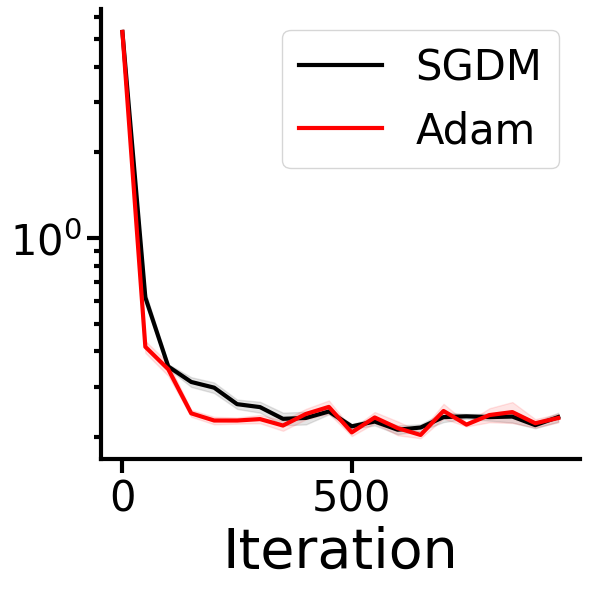

In [ ]:
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)

fig, ax = plt.subplots(1, 1,figsize = (6, 6))

for (alg, toclip, lr) in [('sgd', True, 0.02),('adam', True, 0.02)]:
    losses = torch.zeros(len(seeds), int(max_iters/stride))
    for idx, sd in enumerate(seeds):
        losses[idx] = loss_plots[(alg, toclip, lr, sd, random_number)]
    losses_mean = torch.mean(losses, axis=0)
    losses_std = torch.std(losses, axis=0)
    if alg == 'sgd':
        ax.plot(range(0,max_iters,stride), losses_mean, color = 'black', lw = 3,label='SGDM')
        ax.fill_between(range(0,max_iters,stride), losses_mean-losses_std/4, losses_mean+losses_std/4, color = 'black', alpha = 0.1)
    elif alg == 'adam':
        ax.plot(range(0,max_iters,stride), losses_mean, color = 'red', lw = 3, label='Adam')
        ax.fill_between(range(0,max_iters,stride), losses_mean-losses_std/4, losses_mean+losses_std/4, color = 'red', alpha = 0.1)

    ax.set_xlabel('Iteration',fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=30, width = 3, length = 10)
    ax.tick_params(axis='both', which='minor', labelsize=20, width = 3, length = 5)
    ax.legend(fontsize=30)
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['left'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig(fig_dir + '/loss_layer{}_N{}_{}.pdf'.format(n_layer, N, mode), dpi=600)

In [ ]:
# Print the P matrices from the allparam tensor
allparam = model.allparam.detach().cpu().numpy()  # Convert to numpy array for easier printing
for i in range(model.n_layer):
    for j in range(model.n_head):
        Pij = allparam[i, j, 0, :, :]
        print(f"P matrix at layer {i}, head {j}:")
        print(Pij)
        print()  # Add an empty line for readability

In [ ]:
allparam

array([[[[[ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ]],

         [[-0.44  , -0.0031, -0.0003, -0.01  ,  0.0071],
          [-0.0035, -0.4396, -0.0155, -0.0473, -0.0107],
          [-0.0026, -0.0248, -0.4436,  0.0012,  0.0549],
          [-0.018 ,  0.0023, -0.0312, -0.4467,  0.0176],
          [-0.0002, -0.0225,  0.0431,  0.0367, -0.3898]]]],



       [[[[ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
          [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ]],

         [[-1.6565,  0.0592, -0.0341, -0.0255, -0.0558],
          [ 0.0177, -1.7129,  0.0076, -0.0155,  0.0397],
          [-0.0031, -

In [7]:
import torch
from matplotlib import pyplot as plt
import sys
import time
import os
import numpy as np
import math

##############################################################################################################
# Trains a linear Transformer with 1,2,3,4 layers
# Plots the test loss of trained Transformer against 1,2,3,4 steps of gradient descent (with and without preconditioning)
##############################################################################################################

#use cuda if available, else use cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#torch.cuda.set_device(1)
# import the model and some useful functions
from linear_transformer import Transformer_F, attention, generate_data, in_context_loss, generate_data_inplace

# set up some print options
np.set_printoptions(precision = 2, suppress = True)
torch.set_printoptions(precision=2)

#begin logging
cur_dir = 'log'
os.makedirs(cur_dir, exist_ok=True)
#f = open(cur_dir + '/rotation.log', "a", 1)
#sys.stdout = f

In [8]:
# Set up problem parameters

lr = 0.01
clip_r = 0.01
alg = 'adam'
mode = 'normal'

n_layer = 4  # number of layers of transformer
N = 20     # context length
d = 5        # dimension


n_head = 1  # 1-headed attention
B = 1000  # 1000 minibatch size
var = 0.0001  # initializations scale of transformer parameter
shape_k = 0.1  # shape_k: parameter for Gamma distributed covariates
max_iters = 200  # Number of Iterations to run
hist_stride = 1  # stride for saved model paramters in `train.ipynb'
stride = 100

# a convenience function for taking a step and clipping
def clip_and_step(allparam, optimizer, clip_r = None):
    norm_p=None
    grad_all = allparam.grad
    if clip_r is not None:
        for l in range(grad_all.shape[0]):
            for h in range(grad_all.shape[1]):
                for t in range(grad_all.shape[2]):
                    norm_p = grad_all[l,h,t,:,:].norm().item()
                    if norm_p > clip_r:
                        grad_all[l,h,t,:,:].mul_(clip_r/norm_p)
    optimizer.step()
    return norm_p

#format for saving run data
filename_format = '/variable_L_hist_{}_{}_{}.pth'
n_layers = [1,2,3,4]  # number of layers of transformer
seeds=[0,1,2,3,4]
keys = []
for s in seeds:
    for n_layer in n_layers:
        keys.append((s,n_layer,))

In [12]:
import torch
import numpy as np
import time

# Determine the device to use (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for key in keys:
    sd = key[0]
    n_layer = key[1]
    filename = cur_dir + filename_format.format(n_layer, N, sd)
    print(key)

    prob_seed = sd
    opt_seed = sd

    hist = []

    # Set seed and initialize model
    torch.manual_seed(opt_seed)
    model = Transformer_F(n_layer, 1, N, d, var, 0)
    model.to(device)  # Move the model to the appropriate device

    # Initialize algorithm. Important: set beta = 0.9 for adam, 0.999 is very slow
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.99, 0.9), weight_decay=0)

    # Set seed
    # Sample random rotation matrix
    # Initialize initial training batch
    np.random.seed(prob_seed)
    torch.manual_seed(prob_seed)
    gaus = torch.FloatTensor(5, 5).uniform_(-1, 1).to(device)  # Ensure tensor is on the correct device
    U = torch.linalg.svd(gaus)[0].to(device)
    D = torch.diag(torch.FloatTensor([1, 1, 1, 1, 1])).to(device)
    Z, y = generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z.to(device)
    y = y.to(device)

    for t in range(max_iters):
        if t % 4000 == 0 and t > 1:
            optimizer.param_groups[0]['lr'] = optimizer.param_groups[0]['lr'] * 0.5
        if t % 100 == 0:
            Z, y = generate_data_inplace(Z, U=U, D=D)

        start = time.time()

        # Save model parameters
        if t % stride == 0:
            hist.append(model.allparam.clone().detach())

        loss = in_context_loss(model, Z, y)

        # Compute gradient and take a step
        loss.backward()
        norms = clip_and_step(model.allparam, optimizer, clip_r=clip_r)
        optimizer.zero_grad()

        end = time.time()

        if t % 100 == 0 or t < 5:
            print('iter {} | Loss: {}  time: {}  gradnorm: {}'.format(t, loss.item(), end-start, norms))

    torch.save({'hist': hist, 'U': U, 'D': D}, filename)

In [ ]:
hist[-1]

tensor([[[[[ 0.00,  0.00,  0.00,  0.00,  0.00],
           [ 0.00,  0.00,  0.00,  0.00,  0.00],
           [ 0.00,  0.00,  0.00,  0.00,  0.00],
           [ 0.00,  0.00,  0.00,  0.00,  0.00],
           [ 0.00,  0.00,  0.00,  0.00,  0.00]],

          [[-2.42, -1.84,  0.72,  1.22,  0.25],
           [-1.82, -2.39,  0.68,  0.98,  0.06],
           [ 0.61,  0.73, -0.94, -0.10,  0.19],
           [ 0.48,  1.05, -0.17, -3.09, -1.03],
           [-0.26,  0.13,  0.22, -1.11, -1.15]]]]], device='cuda:0')

In [ ]:
########################################################
# compute test loss for trained linear Transformers
########################################################
loss_dict_zero = {}
store = 0
for sd in seeds:
    key = (sd,)
    loss_dict_zero[key] = torch.zeros(4)
    for n_layer in n_layers:
        # Load parameters for given n_layer and seed
        filename = cur_dir + filename_format.format(n_layer, N, sd)
        hist = torch.load(filename)['hist']
        U = torch.load(filename)['U']
        D = torch.load(filename)['D']

        # Validation set to find the best model and fine-tune gamma_param
        np.random.seed(999)
        torch.manual_seed(999)
        Z_val, y_val = generate_data(mode, N, d, B, shape_k, U, D)
        Z_val = Z_val.to(device)
        y_val = y_val.to(device)
        model = Transformer_F(n_layer, n_head, N, d, var, 0).to(device)

        # Fine-tune gamma on the validation data
        model.gamma.requires_grad = False
        model.alpha.requires_grad = False
        model.allparam.requires_grad = True

        model.allparam.data.copy_(hist[-1])

        # Use Adam optimizer for fine-tuning
        optimizer = torch.optim.Adam([model.alpha, model.gamma], lr=lr)

        fine_tune_iters = 200
        for t in range(fine_tune_iters):  # fine_tune_iters: number of fine-tuning steps
            optimizer.zero_grad()
            loss = in_context_loss(model, Z_val, y_val)
            loss.backward()
            optimizer.step()

        # Generate new test data after fine-tuning gamma
        np.random.seed(99)
        torch.manual_seed(99)
        Z_test, y_test = generate_data(mode, N, d, B, shape_k, U, D)
        Z_test = Z_test.to(device)
        y_test = y_test.to(device)

        # Compute loss with no momentum
        with torch.no_grad():
            loss_dict_zero[key][n_layer - 1] = in_context_loss(model, Z_test, y_test).log().item()

<ipython-input-23-bca4132b37d9>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  hist = torch.load(filename)['hist']
<ipython-input-23-bca4132b37d9>:13: FutureWarning: You 

In [ ]:
########################################################
# compute test loss for trained linear Transformers
########################################################
loss_dict = {}
store = 0
for sd in seeds:
    key = (sd,)
    loss_dict[key] = torch.zeros(4)
    for n_layer in n_layers:
        # Load parameters for given n_layer and seed
        filename = cur_dir + filename_format.format(n_layer, N, sd)
        hist = torch.load(filename)['hist']
        U = torch.load(filename)['U']
        D = torch.load(filename)['D']

        # Validation set to find the best model and fine-tune gamma_param
        np.random.seed(999)
        torch.manual_seed(999)
        Z_val, y_val = generate_data(mode, N, d, B, shape_k, U, D)
        Z_val = Z_val.to(device)
        y_val = y_val.to(device)
        model = Transformer_F(n_layer, n_head, N, d, var, 1).to(device)

        # Fine-tune gamma on the validation data
        model.gamma.requires_grad = True
        model.alpha.requires_grad = True
        model.allparam.requires_grad = True

        model.allparam.data.copy_(hist[-1])

        # Use Adam optimizer for fine-tuning
        optimizer = torch.optim.Adam([model.alpha, model.gamma], lr=lr)

        fine_tune_iters = 200
        for t in range(fine_tune_iters):  # fine_tune_iters: number of fine-tuning steps
            optimizer.zero_grad()
            loss = in_context_loss(model, Z_val, y_val)
            loss.backward()
            optimizer.step()

        # Generate new test data after fine-tuning gamma
        np.random.seed(99)
        torch.manual_seed(99)
        Z_test, y_test = generate_data(mode, N, d, B, shape_k, U, D)
        Z_test = Z_test.to(device)
        y_test = y_test.to(device)

        # Compute loss after fine-tuning and on the new test data
        with torch.no_grad():
            loss_dict[key][n_layer - 1] = in_context_loss(model, Z_test, y_test).log().item()

<ipython-input-24-a6f81563e5b1>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  hist = torch.load(filename)['hist']
<ipython-input-24-a6f81563e5b1>:13: FutureWarning: You 

In [ ]:
# Print the P matrices from the allparam tensor
allparam = model.allparam.detach().cpu().numpy()  # Convert to numpy array for easier printing
for i in range(model.n_layer):
    for j in range(model.n_head):
        Pij = allparam[i, j, 0, :, :]
        print(f"P matrix at layer {i}, head {j}:")
        print(Pij)
        print()  # Add an empty line for readability

In [ ]:
allparam

array([[[[[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ]],

         [[-3.73, -0.84,  0.19,  2.04, -0.7 ],
          [-1.08, -0.74,  0.09,  0.77, -0.41],
          [ 0.33,  0.1 , -1.9 , -0.7 ,  1.12],
          [ 2.08,  0.07, -0.69, -2.01,  0.88],
          [-1.66, -0.25,  0.98,  1.38, -1.79]]]],



       [[[[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ]],

         [[-4.46, -0.02,  0.62,  2.55,  0.05],
          [-1.6 , -0.91, -0.1 ,  1.44, -0.52],
          [ 0.05, -0.77, -2.16,  0.04,  0.6 ],
          [ 2.82, -0.28, -0.44, -3.21,  0.99],
          [-1.24,  0.47,  0.87,  1.35, -1.35]]]],



       [[[[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  

In [ ]:
# Print the gamma parameters from the model
gamma = model.gamma.detach().cpu().numpy()  # Convert to numpy array for easier printing
for i in range(model.n_layer):
    print(f"Gamma parameter at layer {i + 1}: {gamma[i]}")
    print()  # Add an empty line for readability

In [ ]:
gamma

array([0., 0., 0., 0.], dtype=float32)

In [71]:
import torch
import linear_transformer  # your module that has generate_data(...)
import numpy as np
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

###############################################################################
# Batched LFOM: single w, gradient aggregated across the entire batch.
###############################################################################
def do_lfom(Z, gamma_list, numstep):
    """
    Perform a Linear First-Order Method update on *batched* data.

    Z: shape [B, N+1, d+1].
       - For each batch b in [0..B-1],
         the first N rows are training examples (X_b),
         the (N+1)-th row is typically a test example (not used here).
    gamma_list: list of trainable vectors [gamma_0, ..., gamma_{numstep-1}],
                each shape [d].
    numstep: number of unrolled gradient steps.

    Returns:
      w (torch.Tensor): shape [d], single shared parameter vector across the batch.
    """
    B, total_len, d_plus_1 = Z.shape
    d = d_plus_1 - 1
    N = total_len - 1   # First N rows are training rows

    X = Z[:, :N, :d]  # shape [B, N, d]
    Y = Z[:, :N, d]   # shape [B, N]

    # Initialize w
    w = torch.zeros(d, device=device, requires_grad=False)

    grads = []

    for k in range(numstep):
        # Compute forward pass for the batch
        Xw = torch.einsum('bnd,d->bn', X, w)  # shape [B, N]
        residuals = Xw - Y                    # shape [B, N]

        # Compute gradient, averaged over the batch
        grad = torch.einsum('bnd,bn->d', X, residuals) / B  # shape [d]

        # Accumulate this gradient for replay
        grads.append(grad)

        # Weighted sum of all past gradients
        w_update = torch.zeros_like(w)
        for i in range(len(grads)):
            w_update += grads[i] * gamma_list[i]  # elementwise multiply

        # Update w
        w = w - w_update

    return w

###############################################################################
# Evaluate function: average test MSE across the batch
###############################################################################
def eval_w_instance(Z, w):
    """
    Evaluate the learned w on the *last row* of Z for each batch entry.

    Z: shape [B, N+1, d+1].
       - The last row index is N, so Z[:, N, :d] is shape [B, d].
       - The label is Z[:, N, d], shape [B].

    Returns:
      (mse_loss, predictions):
        mse_loss = average MSE across the B tasks, shape []
        predictions = shape [B], the predictions for each batch element.
    """
    B, total_len, d_plus_1 = Z.shape
    d = d_plus_1 - 1
    N = total_len - 1

    Xtest = Z[:, N, :d]  # shape [B, d]
    Ytest = Z[:, N, d]   # shape [B]

    # Dot product across each batch row: 'bd,d->b'
    predictions = torch.einsum('bd,d->b', Xtest, w)  # shape [B]

    # MSE over B
    residuals = predictions - Ytest  # shape [B]
    mse_loss = (residuals**2).mean() # shape []

    return mse_loss, predictions

###############################################################################
# Example "main" code that uses a training loop for gamma
###############################################################################
if __name__ == "__main__":
    # Example hyperparameters
    B = 1000
    N = 20
    d = 5
    shape_k = 1.0
    mode = 'normal'
    n_layers = [1, 2, 3, 4]  # Different numbers of unrolled steps

    # Final test loss matrix
    gd_loss_matrix = torch.zeros(len(n_layers), device=device)

    # Generate training data (batched)
    Z, y_test = linear_transformer.generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z.to(device)  # shape [B, N+1, d+1]

    for n_idx, n_layer in enumerate(n_layers):
        print(f"\n=== Running LFOM with {n_layer} unrolled steps ===")

        # 1) Create trainable gamma's
        gamma_list = [
            torch.nn.Parameter(torch.zeros(d, device=device))
            for _ in range(n_layer)
        ]

        # 2) Optimizer for gamma
        optimizer = optim.Adam(gamma_list, lr=1e-3)

        # Store per-epoch training losses
        num_epochs = 300
        gd_loss = torch.zeros(num_epochs, device=device)

        for epoch in range(num_epochs):
            optimizer.zero_grad()

            # Unroll LFOM
            w = do_lfom(Z, gamma_list, n_layer)

            # Compute the batch-averaged loss
            loss_mse, _ = eval_w_instance(Z, w)

            # Backprop and update gamma
            loss_mse.backward()
            optimizer.step()

            # Store training loss
            gd_loss[epoch] = loss_mse.detach()

            # Optionally print progress
            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch + 1}/{num_epochs}, MSE: {loss_mse.item():.6f}")

        # After training, evaluate final test loss
        w_final = do_lfom(Z, gamma_list, n_layer)
        final_mse, _ = eval_w_instance(Z, w_final)
        print(f"Final test MSE for {n_layer} steps: {final_mse.item():.6f}")

        # Store final loss
        gd_loss_matrix[n_idx] = final_mse.item()

    # Analyze results
    print("\nFinal test MSE for each n_layer:")
    for i, n_layer in enumerate(n_layers):
        print(f"  n_layer={n_layer}, MSE={gd_loss_matrix[i].item():.6f}")

In [72]:
gamma_list

[Parameter containing:
 tensor([0., 0., 0., 0., 0.], requires_grad=True),
 Parameter containing:
 tensor([0., 0., 0., 0., 0.], requires_grad=True),
 Parameter containing:
 tensor([0., 0., 0., 0., 0.], requires_grad=True),
 Parameter containing:
 tensor([0., 0., 0., 0., 0.], requires_grad=True)]

In [73]:
import torch
import linear_transformer  # your module that has generate_data(...)
import numpy as np
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

###############################################################################
# Replaces do_gd with do_lfom (trainable gamma)
###############################################################################
def do_lfom(Z, gamma_list, numstep):
    """
    Perform a Linear First-Order Method update on a single-task dataset Z,
    using a list of trainable gamma vectors (one per step).

    Args:
        Z (torch.Tensor): shape [N+1, d+1].
          The first (N-1) rows are used for training (X, Y).
          The row Z[N-1] is unused (same as old code).
          The row Z[N] is presumably a test example (not used here).
        gamma_list (list[torch.Tensor]): each gamma[i] has shape [d].
        numstep (int): number of unrolled gradient steps.

    Returns:
        w (torch.Tensor): shape [d], final parameter vector.
    """
    device = Z.device
    N = Z.shape[0] - 1
    # Exactly matching your old indexing in do_gd
    X = Z[0 : N-1, 0 : 5]   # shape [N-1, 5]
    Y = Z[0 : N-1, 5]       # shape [N-1]

    # Initialize w as zeros
    w = torch.zeros(X.shape[1], device=device, requires_grad=False)

    grads = []
    for k in range(numstep):
        # 1) Compute forward pass
        Xw = X @ w        # shape [N-1]
        residuals = Xw - Y

        # 2) Compute gradient: grad = X^T * residuals
        grad = X.t() @ residuals  # shape [5]

        # 3) Accumulate this new grad
        grads.append(grad)

        # 4) Weighted sum of all (past) gradients
        w_update = torch.zeros_like(w)
        for i in range(len(grads)):
            w_update += grads[i] * gamma_list[i]  # elementwise multiply

        # 5) Update w
        w = w - w_update

    return w

###############################################################################
# Same eval function as your snippet (no changes needed)
###############################################################################
def eval_w_instance(Z, Ytest, w):
    """
    Evaluate the learned w on the last row of Z (the row index N),
    comparing to Ytest.

    Returns:
      (loss, prediction): scalar MSE loss, scalar prediction
    """
    N = Z.shape[0] - 1
    Xtest = Z[N, 0 : 5]
    prediction = torch.einsum('i,i->', w, Xtest)  # dot product
    return (Ytest - prediction)**2, prediction


###############################################################################
# Example "main" code that uses a training loop for gamma
###############################################################################
# Just placeholders for your existing variables
# (Adjust to your actual values.)
seeds = [0]
n_layers = [1, 2, 3, 4]
mode = 'normal'
N = 20
d = 5
B = 1
shape_k = 1.0

# We'll store final test losses in a matrix => [len(seeds), 4]
gd_loss_matrix = torch.zeros(len(seeds), len(n_layers))

for n_idx, n_layer in enumerate(n_layers):
    print(f"======= n_layer = {n_layer} =======")
    numstep = n_layer

    # For a fair example, fix one seed to generate data
    # In your code, you might do something else with U, D, etc.
    sd = 999
    np.random.seed(sd)
    torch.manual_seed(sd)

    # Generate data => shape [B, N+1, d+1], plus y => shape [B]
    Z_big, y_big = linear_transformer.generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z_big[0].to(device)  # shape [N+1, d+1]
    y_test_scalar = y_big[0].to(device)  # scalar for last row of Z

    # 1) Initialize a list of gamma's (one per step), each shape [5]
    gamma_list = [
        torch.nn.Parameter(torch.zeros(d, device=device))
        for _ in range(numstep)
    ]

    # 2) Create an optimizer for them
    optimizer = optim.Adam(gamma_list, lr=1e-3)

    # We'll store the training MSE each epoch in gd_loss
    num_epochs = 300
    gd_loss = torch.zeros(num_epochs, device=device)

    # 3) Train gamma
    for epoch in range(num_epochs):
        optimizer.zero_grad()

        # Unroll LFOM
        w = do_lfom(Z, gamma_list, numstep)

        # For the "training" objective, let's just do MSE on the first (N-1) points
        # (since your old code used them for the update). Alternatively,
        # you could do the last row's test error, or anything else.
        X_train = Z[0 : (N-1), 0 : 5]  # shape [N-1, 5]
        Y_train = Z[0 : (N-1), 5]     # shape [N-1]

        pred_train = X_train @ w               # shape [N-1]
        residuals = pred_train - Y_train       # shape [N-1]
        loss_train = (residuals**2).mean()     # scalar

        # Backprop through gamma
        loss_train.backward()
        optimizer.step()

        # Store the training loss in gd_loss
        gd_loss[epoch] = loss_train.detach()

    # Print the final training loss after training
    print(f"  Final training loss = {gd_loss[-1].item():.6f}")

    # Evaluate on the last row
    w_final = do_lfom(Z, gamma_list, numstep)  # forward once more
    test_loss, test_pred = eval_w_instance(Z, y_test_scalar, w_final)
    print(f"  Test loss = {test_loss.item():.6f}")

    # If you had multiple seeds, you'd do:
    #   for idx, seed in enumerate(seeds):
    #       ...
    #       store final test loss in gd_loss_matrix[idx, n_idx]
    # But for now, we just store the single-seed result:
    gd_loss_matrix[0, n_idx] = test_loss.item()

# Now we can analyze gd_loss_matrix if desired
print("gd_loss_matrix:", gd_loss_matrix)
gd_loss_mean = gd_loss_matrix.log().mean(dim=0)
gd_loss_std  = gd_loss_matrix.log().std(dim=0)
print("Mean log test loss:", gd_loss_mean)
print("Std  log test loss:", gd_loss_std)

###############################################################################
# At the end, you also have the per-epoch training loss stored in 'gd_loss'
# for the *last* run above, if you want to do something with it.
# If you'd like to keep each n_layer's training curve, make a list of gd_loss.
###############################################################################


<ipython-input-73-1ea25f5c9f8a>:161: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  gd_loss_std  = gd_loss_matrix.log().std(dim=0)


In [74]:
gd_loss_mean

tensor([ -6.64,  -8.05, -10.43, -12.41])

In [75]:
gamma_list

[Parameter containing:
 tensor([ 0.00,  0.00, -0.00,  0.00,  0.00], requires_grad=True),
 Parameter containing:
 tensor([ 0.00,  0.00, -0.00,  0.02,  0.00], requires_grad=True),
 Parameter containing:
 tensor([0.00, 0.01, 0.00, 0.06, 0.01], requires_grad=True),
 Parameter containing:
 tensor([0.01, 0.01, 0.02, 0.08, 0.01], requires_grad=True)]

In [21]:
import torch
import torch.optim as optim
import numpy as np

# Make sure to import your code that has generate_data(...)
import linear_transformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

###############################################################################
# Batched LFOM: single w, gradient aggregated across the entire batch.
###############################################################################
def do_lfom(Z, gamma_list, numstep):
    """
    Perform a Linear First-Order Method update on *batched* data.

    Z: shape [B, N+1, d+1].
       - For each batch b in [0..B-1],
         the first N rows are training examples (X_b),
         the (N+1)-th row is typically a test example (not used here).
    gamma_list: list of trainable vectors [gamma_0, ..., gamma_{numstep-1}],
                each shape [d].
    numstep: number of unrolled gradient steps.

    Returns:
      w (torch.Tensor): shape [d], single shared parameter vector across the batch.
    """
    B, total_len, d_plus_1 = Z.shape
    d = d_plus_1 - 1
    N = total_len - 1   # So the first N rows per batch are "training" rows

    # We'll take the *first N rows* minus 1?
    # Based on your old code, you sometimes used N-1 vs N.
    # But typically you'd do X = Z[:, :N, :d], Y = Z[:, :N, d].
    # Let's do exactly that: all first N rows for training.
    X = Z[:, :N, :d]  # shape [B, N, d]
    Y = Z[:, :N, d]   # shape [B, N]

    # Initialize w
    # requires_grad=False because we'll only update w via the formula;
    # gamma is what's being trained by Adam.
    w = torch.zeros(d, device=device, requires_grad=False)

    # We'll store the past gradients for the replay logic
    grads = []

    for k in range(numstep):
        # 1) Forward pass: X @ w => shape [B, N]
        #    We broadcast w of shape [d] across the batch dimension
        #    => X.shape [B, N, d], w.shape [d].
        #    We'll use einsum or matmul:
        Xw = torch.einsum('bnd,d->bn', X, w)  # shape [B, N]

        # 2) Residuals => shape [B, N]
        residuals = Xw - Y

        # 3) Compute gradient, aggregated over the entire batch => shape [d]
        #    We do: grad = sum_{b=1..B} X_b^T * residuals_b
        #    => with einsum: 'bnd,bn->d'
        grad = torch.einsum('bnd,bn->d', X, residuals)  # shape [d]

        # 4) Add this grad to our list for replay
        grads.append(grad)

        # 5) Weighted sum of all past grads
        w_update = torch.zeros_like(w)
        for i in range(len(grads)):
            w_update += grads[i] * gamma_list[i]  # elementwise multiply

        # 6) Update w
        w = w - w_update

    return w

###############################################################################
# Evaluate function: average test MSE across the batch
###############################################################################
def eval_w_instance(Z, w):
    """
    Evaluate the learned w on the *last row* of Z for each batch entry.

    Z: shape [B, N+1, d+1].
       - The last row index is N, so Z[:, N, :d] is shape [B, d].
       - The label is Z[:, N, d], shape [B].
    w: shape [d].

    Returns:
      (mse_loss, predictions):
        mse_loss = average MSE across the B tasks, shape []
        predictions = shape [B], the predictions for each batch element.
    """
    B, total_len, d_plus_1 = Z.shape
    d = d_plus_1 - 1
    N = total_len - 1

    Xtest = Z[:, N, :d]  # shape [B, d]
    Ytest = Z[:, N, d]   # shape [B]

    # Dot product across each batch row: 'bd,d->b'
    predictions = torch.einsum('bd,d->b', Xtest, w)  # shape [B]

    # MSE over B
    residuals = predictions - Ytest  # shape [B]
    mse_loss = (residuals**2).mean() # shape []

    return mse_loss, predictions

###############################################################################
# Example "main" code
###############################################################################
if __name__ == "__main__":
    # For illustration: we choose B=1000, N=20, d=5
    B = 1000
    N = 20
    d = 5
    shape_k = 1.0
    mode = 'normal'  # from your linear_transformer code

    # We'll do multiple "n_layer" runs
    n_layers = [1, 2, 3, 4]
    # We'll store final test MSE for each n_layer
    final_test_mse = {}

    # Generate data for training
    # Z shape => [B, N+1, d+1], plus y => [B], but we won't use y from generate_data
    # because we store everything in Z.
    torch.manual_seed(0)
    Z, y_test = linear_transformer.generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z.to(device)

    for n_layer in n_layers:
        print(f"\n=== Running LFOM with {n_layer} unrolled steps ===")

        # 1) Create trainable gamma's: each is shape [d]
        gamma_list = [
            torch.nn.Parameter(torch.zeros(d, device=device))
            for _ in range(n_layer)
        ]

        # 2) An optimizer for them
        optimizer = optim.Adam(gamma_list, lr=1e-3)

        # We'll track training losses over epochs in gd_loss
        num_epochs = 300
        gd_loss = torch.zeros(num_epochs, device=device)

        for epoch in range(num_epochs):
            optimizer.zero_grad()

            # a) Unroll LFOM
            w = do_lfom(Z, gamma_list, n_layer)

            # b) Evaluate the *batch-averaged* test MSE on the last row
            #    Or if you prefer, you can evaluate a "training" MSE on rows [:N],
            #    but commonly you'd want test or validation objective.
            #    We'll do test to drive gamma's learning.
            loss_mse, preds = eval_w_instance(Z, w)
            # shape of loss_mse => [] (scalar)

            # c) Backprop => update gamma
            loss_mse.backward()
            optimizer.step()

            gd_loss[epoch] = loss_mse.detach()

            # Optional progress print
            # if (epoch+1) % 50 == 0:
            #     print(f"Epoch {epoch+1}/{num_epochs}, MSE: {loss_mse.item():.6f}")

        # After training, do a final forward pass
        w_final = do_lfom(Z, gamma_list, n_layer)
        final_mse, final_preds = eval_w_instance(Z, w_final)
        print(f"Final test MSE after training = {final_mse.item():.6f}")

        # Store final result
        final_test_mse[n_layer] = final_mse.item()

        # Now gd_loss contains the per-epoch MSE over the batch,
        # which you can examine or plot:
        # e.g.,  print(gd_loss.cpu().numpy())

    print("\nSummary of final test MSE for each n_layer:")
    for nl in n_layers:
        print(f"  n_layer={nl}, MSE={final_test_mse[nl]:.6f}")

In [22]:
final_test_mse

{1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}

In [109]:
import torch
import linear_transformer
import numpy as np
import torch.optim as optim

B = 10

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# LFOM update function with Hadamard product (batch processing)
def do_lfom(Z, numstep, gamma):
    N = Z.shape[1] - 1  # sequence_length - 1
    X = Z[:, 0:N-1, 0:5]  # [batch_size, N-1, 5]
    Y = Z[:, 0:N-1, 5]    # [batch_size, N-1]
    w = torch.zeros((X.shape[0], X.shape[2]), requires_grad=True).to(device)  # [batch_size, 5]

    grads = []

    for k in range(numstep):
        # Compute gradient for the current iterate
        Xw = torch.einsum('bij,bj->bi', X, w)  # [batch_size, N-1]
        residuals = Xw - Y  # [batch_size, N-1]
        grad = torch.einsum('bij,bi->bj', X, residuals)  # [batch_size, 5]
        grads.append(grad)

        # Apply LFOM update using learned gamma matrices
        w_update = torch.zeros_like(w)
        for i in range(len(grads)):
            gamma_i = gamma[i]  # [5]
            w_update += grads[i] * gamma_i  # Element-wise product

        w = w - w_update  # Update the weights

    return w  # [batch_size, 5]

# Evaluation function for batch instances
def eval_w_instance(Z, Ytest, w):
    N = Z.shape[1] - 1
    Xtest = Z[:, N, 0:5]  # [batch_size, 5]
    prediction = torch.einsum('bi,bi->b', w, Xtest)  # [batch_size]
    loss = (Ytest - prediction) ** 2  # [batch_size]
    return loss, prediction

# Define seeds and layers
seeds = [0]  # Example seeds
n_layers = [1, 2, 3, 4]  # Example number of layers

# Initialize loss matrix
gd_loss_matrix = torch.zeros(len(seeds), len(n_layers))

# Main loop to find the best eta and evaluate performance
for n_idx, n_layer in enumerate(n_layers):
    sd = 1
    numstep = n_layer

    # Generate U and D matrices (placeholder)
    np.random.seed(sd)
    torch.manual_seed(sd)
    gaus = torch.FloatTensor(5, 5).uniform_(-1, 1).to(device)
    U = torch.linalg.svd(gaus)[0].to(device)
    D = torch.diag(torch.FloatTensor([1, 1, 1, 1, 1])).to(device)

    # Generate training data
    np.random.seed(999)
    torch.manual_seed(999)
    Z, y = generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z.to(device)
    y = y.to(device)

    # Initialize gamma matrices as learnable parameters
    gamma = [torch.zeros(5, requires_grad=True).to(device) for _ in range(numstep)]
    optimizer = optim.Adam(gamma, lr=0.01)

    num_epochs = 1000

    # Training phase
    for k in range(num_epochs):
        optimizer.zero_grad()
        w = do_lfom(Z, numstep, gamma)
        gd_loss, gd_pred = eval_w_instance(Z, y, w)
        total_loss = gd_loss.sum()
        total_loss.backward()
        optimizer.step()
        mean_loss = total_loss / Z.shape[0]
        #print(f'n_layer: {n_layer}, loss: {mean_loss.item()}')

    # Evaluation phase (without parameter updates)
    for idx, sd in enumerate(seeds):
        torch.manual_seed(sd)
        Z_test, y_test = Z, y
        Z_test = Z_test.to(device)
        y_test = y_test.to(device)

        with torch.no_grad():
            w = do_lfom(Z_test, numstep, gamma)
            gd_loss, gd_pred = eval_w_instance(Z_test, y_test, w)
            total_loss = gd_loss.sum()

        mean_loss = total_loss / Z.shape[0]
        gd_loss_matrix[idx, n_idx] = mean_loss.item()

# Compute mean and std of log test loss for plotting
gd_loss_mean = gd_loss_matrix.log().mean(dim=0)
gd_loss_std = gd_loss_matrix.log().std(dim=0)

# Print the results
print('Mean log test loss:', gd_loss_mean)
print('Std of log test loss:', gd_loss_std)

<ipython-input-109-06c23e882713>:105: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  gd_loss_std = gd_loss_matrix.log().std(dim=0)


In [110]:
gd_loss_mean

tensor([ -1.53,  -3.52, -23.19, -26.50])

In [108]:
gamma

[tensor([0.03, 0.01, 0.01, 0.03, 0.02], requires_grad=True),
 tensor([-0.02, -0.00, -0.01, -0.02, -0.01], requires_grad=True),
 tensor([ 0.09,  0.03,  0.03,  0.06, -0.00], requires_grad=True),
 tensor([0.11, 0.06, 0.04, 0.10, 0.06], requires_grad=True)]

In [51]:
B = 1

import torch
import numpy as np

# Conjugate Gradient Descent function
def do_cgd(Z, numstep, alphas, betas):
    N = Z.shape[0] - 1
    X = Z[0:N-1, 0:5]
    Y = Z[0:N-1, 5]
    w = torch.zeros(X.shape[1]).to(device)

    # Initial gradient and direction
    r = torch.einsum('ik,ij,j->k', X, X, w) - torch.einsum('ik,i->k', X, Y)
    p = -r

    for k in range(numstep):
        Xp = torch.einsum('ik,ij,j->k', X, X, p)
        alpha = torch.dot(r, r) / torch.dot(p, Xp)
        alphas.append(alpha.item())  # Store the alpha value

        w = w + alpha * p  # Update the weight

        r_new = r + alpha * Xp
        beta = torch.dot(r_new, r_new) / torch.dot(r, r)
        betas.append(beta.item())

        p = -r_new + beta * p  # Update direction

        r = r_new

    return w

# Evaluation function for an instance
def eval_w_instance(Z, Ytest, w):
    N = Z.shape[0] - 1
    Xtest = Z[N, 0:5]
    prediction = torch.einsum('i,i->', w, Xtest)
    return (Ytest - prediction)**2, prediction

# Initialization of loss matrix
gd_loss_matrix = torch.zeros(len(seeds), 4)

average_alphas_per_layer = []
average_betas_per_layer = []

# Main loop to evaluate performance
for n_layer in n_layers:

    alphas = []  # Initialize alpha list
    betas = []   # Initialize beta list

    # First, find the best eta
    sd = 1
    best_loss = 10000
    best_eta = 0
    numstep = n_layer

    # Load UD matrices
    filename = cur_dir + filename_format.format(n_layer, N, sd)
    U = torch.load(filename)['U']
    D = torch.load(filename)['D']
    B=1000
    # Generate test data using seed 999
    np.random.seed(999)
    torch.manual_seed(999)
    Z, y = generate_data(mode, N, d, B, shape_k, U, D)
    #Z, y = Z_val, y_val
    Z = Z.to(device)
    y = y.to(device)

    # Done generating data

    #for eta in [0.008, 0.01, 0.02, 0.04, 0.08, 0.16]:
    #    ### Start of evaluate mean loss ###
    #    total_loss = 0
    #    for i in range(Z.shape[0]):
    #        Zi = Z[i, :, :]
    #        Ytesti = y[i]
    #        w = do_cgd(Zi, eta, numstep)  # Use do_cgd instead of do_gd
    #        gd_loss, gd_pred = eval_w_instance(Zi, Ytesti, w)
    #        total_loss = total_loss + gd_loss
    #    mean_loss = total_loss / 5000
    #    ### End of evaluate mean loss ###
    #    print('eta: {}, loss: {}'.format(eta, mean_loss))
    #    if (mean_loss < best_loss):
    #        best_eta = eta
    #        best_loss = mean_loss
    #print('best eta: {} for n_layer={}'.format(best_eta, n_layer))


    # Now do actual evaluation
    for sd in seeds:
        opt_seed = sd

        filename = cur_dir + filename_format.format(n_layer, N, sd)
        U = torch.load(filename)['U']
        D = torch.load(filename)['D']

        # Generate test data
        torch.manual_seed(sd)
        Z, y = generate_data(mode, N, d, B, shape_k, U, D)
        #Z, y = Z_val, y_val
        Z = Z.to(device)
        y = y.to(device)

        # Done generating data
        #eta = best_eta

        ### Start of evaluate mean loss ###
        total_loss = 0
        for i in range(Z.shape[0]):
            Zi = Z[i, :, :]
            Ytesti = y[i]
            w = do_cgd(Zi, numstep, alphas, betas)  # Use do_cgd instead of do_gd
            gd_loss, gd_pred = eval_w_instance(Zi, Ytesti, w)
            total_loss = total_loss + gd_loss
        mean_loss = total_loss / Z.shape[0]
        gd_loss_matrix[sd, n_layer-1] = mean_loss

    average_alpha = sum(alphas) / len(alphas)
    average_alphas_per_layer.append(average_alpha)

    average_beta = sum(betas) / len(betas)
    average_betas_per_layer.append(average_beta)

# Compute mean and std of log test loss for plotting
gd_loss_mean = gd_loss_matrix.log().mean(dim=0)
gd_loss_std = gd_loss_matrix.log().var(dim=0)**0.5

<ipython-input-51-ef87466bc36f>:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  U = torch.load(filename)['U']
<ipython-input-51-ef87466bc36f>:62: FutureWarning: You are us

In [52]:
gd_loss_mean

tensor([-0.08, -1.67, -3.45, -6.41])

In [ ]:
import torch
import numpy as np
import time

# Determine the device to use (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for key in keys:
    sd = key[0]
    n_layer = key[1]
    filename = cur_dir + filename_format.format(n_layer, N, sd)
    print(key)

    prob_seed = sd
    opt_seed = sd

    hist = []

    # Set seed and initialize model
    torch.manual_seed(opt_seed)
    model = Transformer_F(n_layer, 1, N, d, var, 0)
    model.to(device)  # Move the model to the appropriate device

    # Initialize algorithm. Important: set beta = 0.9 for adam, 0.999 is very slow
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.99, 0.9), weight_decay=0)

    # Set seed
    # Sample random rotation matrix
    # Initialize initial training batch

    np.random.seed(prob_seed)
    torch.manual_seed(prob_seed)
    gaus = torch.FloatTensor(5, 5).uniform_(-1, 1).to(device)  # Ensure tensor is on the correct device
    U = torch.linalg.svd(gaus)[0].to(device)
    D = torch.diag(torch.FloatTensor([1, 1, 1, 1, 1])).to(device)
    Z, y = generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z.to(device)
    y = y.to(device)

    for t in range(max_iters):
        if t % 4000 == 0 and t > 1:
            optimizer.param_groups[0]['lr'] = optimizer.param_groups[0]['lr'] * 0.5
        if t % 100 == 0:
            Z, y = generate_data_inplace(Z, U=U, D=D)

        start = time.time()

        # Save model parameters
        if t % stride == 0:
            hist.append(model.allparam.clone().detach())

        loss = in_context_loss(model, Z, y)

        # Compute gradient and take a step
        loss.backward()
        norms = clip_and_step(model.allparam, optimizer, clip_r=clip_r)
        optimizer.zero_grad()

        end = time.time()

        if t % 100 == 0 or t < 5:
            print('iter {} | Loss: {}  time: {}  gradnorm: {}'.format(t, loss.item(), end-start, norms))

    torch.save({'hist': hist, 'U': U, 'D': D}, filename)

(0, 1)
iter 0 | Loss: 4.824751377105713  time: 0.008519411087036133  gradnorm: 4.498096466064453
iter 1 | Loss: 4.698563098907471  time: 0.007769346237182617  gradnorm: 4.403742790222168
iter 2 | Loss: 4.579818248748779  time: 0.007696866989135742  gradnorm: 4.313614845275879
iter 3 | Loss: 4.4679999351501465  time: 0.0073206424713134766  gradnorm: 4.228224277496338
iter 4 | Loss: 4.361997604370117  time: 0.007597684860229492  gradnorm: 4.147055625915527
iter 100 | Loss: 1.3290138244628906  time: 0.007303953170776367  gradnorm: 1.6469680070877075
(0, 2)
iter 0 | Loss: 4.824460029602051  time: 0.015900611877441406  gradnorm: 4.49813175201416
iter 1 | Loss: 4.5812296867370605  time: 0.01695561408996582  gradnorm: 4.255408763885498
iter 2 | Loss: 4.364694118499756  time: 0.016646862030029297  gradnorm: 4.04613733291626
iter 3 | Loss: 4.168372631072998  time: 0.01669764518737793  gradnorm: 3.860206127166748
iter 4 | Loss: 3.9865622520446777  time: 0.01573467254638672  gradnorm: 3.688262701

In [ ]:
import torch
import numpy as np
import time

# Determine the device to use (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for key in keys:
    sd = key[0]
    n_layer = key[1]
    filename = cur_dir + filename_format.format(n_layer, N, sd)
    print(key)

    prob_seed = sd
    opt_seed = sd

    hist = []

    # Set seed and initialize model
    torch.manual_seed(opt_seed)
    model = Transformer_F(n_layer, 1, N, d, var, 0)
    model.to(device)  # Move the model to the appropriate device

    # Initialize algorithm. Important: set beta = 0.9 for adam, 0.999 is very slow
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.99, 0.9), weight_decay=0)

    # Set seed
    # Sample random rotation matrix
    # Initialize initial training batch

    np.random.seed(prob_seed)
    torch.manual_seed(prob_seed)
    gaus = torch.FloatTensor(5, 5).uniform_(-1, 1).to(device)  # Ensure tensor is on the correct device
    U = torch.linalg.svd(gaus)[0].to(device)
    D = torch.diag(torch.FloatTensor([1, 1, 1, 1, 1])).to(device)
    Z, y = generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z.to(device)
    y = y.to(device)

    for t in range(max_iters):
        if t % 4000 == 0 and t > 1:
            optimizer.param_groups[0]['lr'] = optimizer.param_groups[0]['lr'] * 0.5
        if t % 100 == 0:
            Z, y = generate_data_inplace(Z, U=U, D=D)

        start = time.time()

        # Save model parameters
        if t % stride == 0:
            hist.append(model.allparam.clone().detach())

        loss = in_context_loss(model, Z, y)

        # Compute gradient and take a step
        loss.backward()
        norms = clip_and_step(model.allparam, optimizer, clip_r=clip_r)
        optimizer.zero_grad()

        end = time.time()

        if t % 100 == 0 or t < 5:
            print('iter {} | Loss: {}  time: {}  gradnorm: {}'.format(t, loss.item(), end-start, norms))

    torch.save({'hist': hist, 'U': U, 'D': D}, filename)

(0, 1)
iter 0 | Loss: 4.824751377105713  time: 0.008519411087036133  gradnorm: 4.498096466064453
iter 1 | Loss: 4.698563098907471  time: 0.007769346237182617  gradnorm: 4.403742790222168
iter 2 | Loss: 4.579818248748779  time: 0.007696866989135742  gradnorm: 4.313614845275879
iter 3 | Loss: 4.4679999351501465  time: 0.0073206424713134766  gradnorm: 4.228224277496338
iter 4 | Loss: 4.361997604370117  time: 0.007597684860229492  gradnorm: 4.147055625915527
iter 100 | Loss: 1.3290138244628906  time: 0.007303953170776367  gradnorm: 1.6469680070877075
(0, 2)
iter 0 | Loss: 4.824460029602051  time: 0.015900611877441406  gradnorm: 4.49813175201416
iter 1 | Loss: 4.5812296867370605  time: 0.01695561408996582  gradnorm: 4.255408763885498
iter 2 | Loss: 4.364694118499756  time: 0.016646862030029297  gradnorm: 4.04613733291626
iter 3 | Loss: 4.168372631072998  time: 0.01669764518737793  gradnorm: 3.860206127166748
iter 4 | Loss: 3.9865622520446777  time: 0.01573467254638672  gradnorm: 3.688262701

In [ ]:
import torch
import numpy as np
import time

# Determine the device to use (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for key in keys:
    sd = key[0]
    n_layer = key[1]
    filename = cur_dir + filename_format.format(n_layer, N, sd)
    print(key)

    prob_seed = sd
    opt_seed = sd

    hist = []

    # Set seed and initialize model
    torch.manual_seed(opt_seed)
    model = Transformer_F(n_layer, 1, N, d, var, 0)
    model.to(device)  # Move the model to the appropriate device

    # Initialize algorithm. Important: set beta = 0.9 for adam, 0.999 is very slow
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.99, 0.9), weight_decay=0)

    # Set seed
    # Sample random rotation matrix
    # Initialize initial training batch
    np.random.seed(prob_seed)
    torch.manual_seed(prob_seed)
    gaus = torch.FloatTensor(5, 5).uniform_(-1, 1).to(device)  # Ensure tensor is on the correct device
    U = torch.linalg.svd(gaus)[0].to(device)
    D = torch.diag(torch.FloatTensor([1, 1, 1, 1, 1])).to(device)
    Z, y = generate_data(mode, N, d, B, shape_k, U, D)
    Z = Z.to(device)
    y = y.to(device)

    for t in range(max_iters):
        if t % 4000 == 0 and t > 1:
            optimizer.param_groups[0]['lr'] = optimizer.param_groups[0]['lr'] * 0.5
        if t % 100 == 0:
            Z, y = generate_data_inplace(Z, U=U, D=D)

        start = time.time()

        # Save model parameters
        if t % stride == 0:
            hist.append(model.allparam.clone().detach())

        loss = in_context_loss(model, Z, y)

        # Compute gradient and take a step
        loss.backward()
        norms = clip_and_step(model.allparam, optimizer, clip_r=clip_r)
        optimizer.zero_grad()

        end = time.time()

        if t % 100 == 0 or t < 5:
            print('iter {} | Loss: {}  time: {}  gradnorm: {}'.format(t, loss.item(), end-start, norms))

    torch.save({'hist': hist, 'U': U, 'D': D}, filename)

(0, 1)
iter 0 | Loss: 4.824751377105713  time: 0.008519411087036133  gradnorm: 4.498096466064453
iter 1 | Loss: 4.698563098907471  time: 0.007769346237182617  gradnorm: 4.403742790222168
iter 2 | Loss: 4.579818248748779  time: 0.007696866989135742  gradnorm: 4.313614845275879
iter 3 | Loss: 4.4679999351501465  time: 0.0073206424713134766  gradnorm: 4.228224277496338
iter 4 | Loss: 4.361997604370117  time: 0.007597684860229492  gradnorm: 4.147055625915527
iter 100 | Loss: 1.3290138244628906  time: 0.007303953170776367  gradnorm: 1.6469680070877075
(0, 2)
iter 0 | Loss: 4.824460029602051  time: 0.015900611877441406  gradnorm: 4.49813175201416
iter 1 | Loss: 4.5812296867370605  time: 0.01695561408996582  gradnorm: 4.255408763885498
iter 2 | Loss: 4.364694118499756  time: 0.016646862030029297  gradnorm: 4.04613733291626
iter 3 | Loss: 4.168372631072998  time: 0.01669764518737793  gradnorm: 3.860206127166748
iter 4 | Loss: 3.9865622520446777  time: 0.01573467254638672  gradnorm: 3.688262701

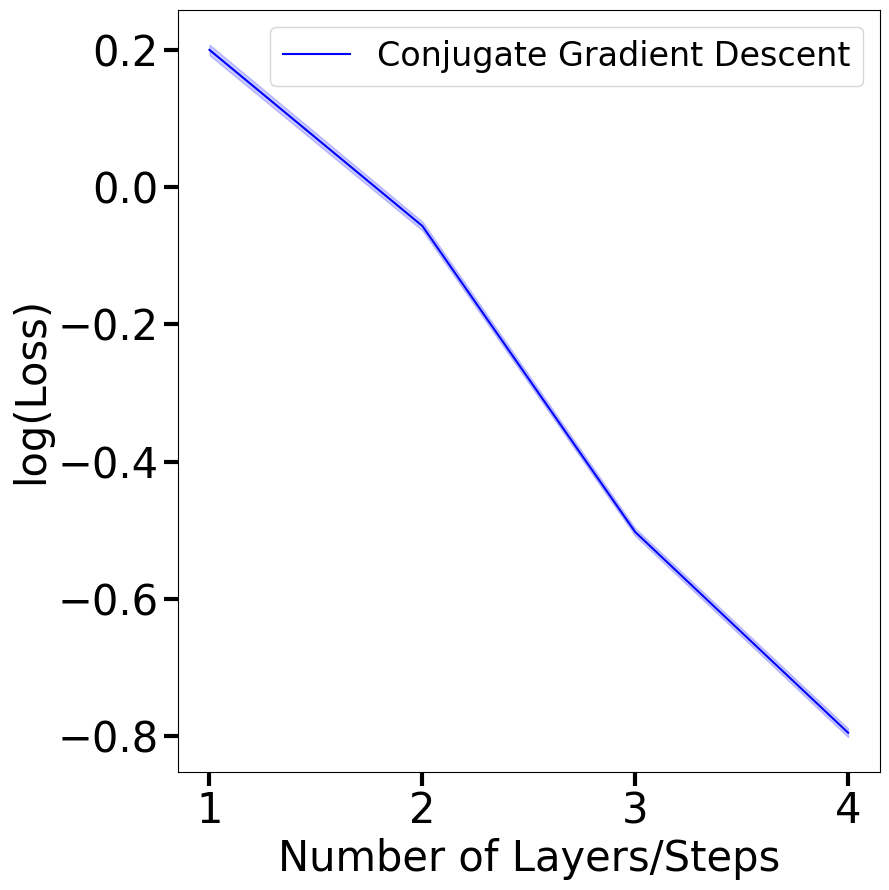

In [ ]:
####################################
# plot final test loss against N
####################################

fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)

fig, ax = plt.subplots(1, 1,figsize = (9, 9))

#losses = torch.zeros(len(seeds), len(n_layers))
#keys = loss_dict.keys()
#for idx, key in enumerate(keys):
#    losses[idx,:] = loss_dict[key]
#losses_mean = torch.mean(losses, axis=0)
#losses_std = torch.std(losses, axis=0)/10

#losses_zero = torch.zeros(len(seeds), len(n_layers))
#keys = loss_dict_zero.keys()
#for idx, key in enumerate(keys):
#    losses_zero[idx,:] = loss_dict_zero[key]
#losses_mean_zero = torch.mean(losses_zero, axis=0)
#losses_std_zero = torch.std(losses_zero, axis=0)/10

plt.plot(n_layers, gd_loss_mean, color='blue', label='Conjugate Gradient Descent')
plt.fill_between(n_layers, gd_loss_mean - gd_loss_std/10, gd_loss_mean + gd_loss_std/10, color='blue', alpha=0.2)

#ax.plot(n_layers, losses_mean, color = 'green', lw = 3, label='Linear Transformer (Pre) GD++')
#ax.fill_between(n_layers, losses_mean-losses_std, losses_mean+losses_std, color = 'green', alpha = 0.2)

#ax.plot(n_layers, losses_mean_zero, color = 'red', lw = 3, label='LFOM Memformer with GD++')
#ax.fill_between(n_layers, losses_mean_zero-losses_std_zero, losses_mean_zero+losses_std_zero, color = 'red', alpha = 0.2)

plt.ylabel('log(Loss)',fontsize=30)
plt.xlabel('Number of Layers/Steps',fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=30, width = 3, length = 10)
ax.tick_params(axis='both', which='minor', labelsize=20, width = 3, length = 5)
ax.legend(fontsize=24)
#ax.set_yscale('log')


plt.tight_layout()
plt.savefig(fig_dir + '/variable-L-plot.pdf', dpi=600)